- Train the model to perform the task, but not to learn the human behavior -> Variants of solutions 

- Dynamics of hidden states across different task conditions

- Interpretate the dynamics of RNN or GRU

Plan:
1. To learn the behavior, train the GRU models on full data (all tasks ?, before: single task with a session-level split)
    1. Try CV to get a good hyperparameters (?)
2. Analyze the dynamics
    - Hidden states: PCA, etc.
    - Gates: short-term vs long-term pattern

    



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# 0 Load Data

Each experimental run consisted of one fixed training task (100 trials) followed by five randomly selected tasks (200 trials each). Some (37%) task sessions were followed by an additional post-learning retention test. All tasks were served via the Cognition.run platform using a flexible jsPsych pipeline. Experimental runs were approximately 45 minutes in duration. Incomplete task sessions were excluded. Data contained within this repository have not been subject to any additional exclusions, e.g. due to low response accuracy. Data have been stripped of identifying characteristics for participant privacy.

In [21]:
from DataManager import DataManager

# search common local folders for azulejos csv files. Add yours to the list if you have the data loaded.
candidate_dirs = [
    Path.cwd() / "data" / "OSF",
    Path.cwd() / "azulejos_data",
    Path.cwd() / "OSF",
]

local_data_dir = None
for folder in candidate_dirs:
    csv_files = sorted(folder.glob("*.csv"))  # collect csv candidates in this folder
    if csv_files:
        local_data_dir = str(folder)
        break

if local_data_dir is None:
    print("No local Azulejos CSV files were found.")
    print("Please place the data in one of the following folders and rerun this cell:")
    for folder in candidate_dirs:
        print(f"  - {folder}")
    local_data_dir = str(candidate_dirs[0])  # default to first candidate folder
    print(f"Defaulting to first candidate folder: {local_data_dir}\nIMPORTANT: Specify a download limit to attempt loading OSF data directly (might be slow).")


print(f"Using local dataset directory: {local_data_dir}")
DM = DataManager(data_dir=local_data_dir, download_limit=419)  # parse local files into model-ready structures, will download only if not locally available


Using local dataset directory: /Users/eastos/Projects/IICCSSS_2026_RL_Behavioral_Modeling/data/OSF
Local data found with 419 files. Skipping OSF download.
Formatting data for models...


100%|██████████| 419/419 [00:12<00:00, 32.62it/s]


# 1 Inspection of the Data

In [12]:
# you can also index the DM's df directly to inspect the data (and filter and stuff)
print(DM.df.columns)
DM.df.head()

Index(['subject_id', 'task_id', 'task_type', 'n_actions', 'actions', 'rewards',
       'best_actions', 'action_reward_probs', 'X', 'Y'],
      dtype='object')


,subject_id,task_id,task_type,n_actions,actions,rewards,best_actions,action_reward_probs,X,Y
0,121,task_6504.0_run_1,states_and_actions,3,"[2, 0, 1, 2, 1, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0, ...","[0.0, 0.0, 73.0, 0.0, 68.0, 87.0, 74.0, 0.0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[41.88, 20.29268292682927, 41.76190476190476]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[2, 0, 1, 2, 1, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0, ..."
1,121,task_620.0_run_2,states_times_actions,4,"[2, 1, 3, 0, 2, 1, 2, 3, 2, 1, 1, 2, 3, 0, 2, ...","[58.0, 0.0, 0.0, 0.0, 58.0, 0.0, 19.0, 0.0, 0....","[2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 1, 2, 2, ...","[17.1875, 17.032258064516128, 24.0344827586206...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[2, 1, 3, 0, 2, 1, 2, 3, 2, 1, 1, 2, 3, 0, 2, ..."
2,121,task_8012.0_run_3,states,3,"[0, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, ...","[0.0, 14.0, 4.0, 50.0, 8.0, 48.0, 5.0, 46.0, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.0, 46.39795918367347, 48.98]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[0, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, ..."
3,121,task_2.0_run_4,states_and_actions,2,"[1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, ...","[100.0, 100.0, 0.0, 0.0, 100.0, 100.0, 100.0, ...","[1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, ...","[45.45454545454545, 63.909774436090224]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0,...","[1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, ..."
4,121,task_100808.0_run_5,states_and_actions,3,"[1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 2, 2, 1, 2, ...","[0.0, 0.0, 0.0, 57.0, 59.0, 57.0, 62.0, 68.0, ...","[2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 2, ...","[51.55789473684211, 37.93939393939394, 43.9722...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 2, 2, 1, 2, ..."


In [5]:
# inspect dataset structure before modeling.
# retrieve high-level dataset description.
summary = DM.get_dataset_description()
print("Dataset overview:")
for key, value in summary.items():
    if isinstance(value, list):
        print(f"  {key}: {len(value)} entries")
    else:
        print(f"  {key}: {value}")

# summarize number of tasks per family.
feature_summary = (
    DM.df[["task_id", "task_type", "n_actions"]]
    .drop_duplicates()  # keep one metadata row per task
    .groupby("task_type")
    .agg(n_tasks=("task_id", "nunique"), n_actions=("n_actions", "first"))  # aggregate family counts
    .reset_index()
)
print("\nTask families in the dataset:")
print(feature_summary)

# inspect one representative session record.
example_row = DM.df.iloc[0]
print("\nExample session:")
print(f"  subject_id: {example_row['subject_id']}")
print(f"  task_id: {example_row['task_id']}")
print(f"  task_type: {example_row['task_type']}")
print(f"  n_actions: {example_row['n_actions']}")
print(f"  first 12 actions: {example_row['actions'][:12].tolist()}")
print(f"  first 12 rewards: {example_row['rewards'][:12].tolist()}")

# select one task for downstream model fitting.
task_ids_sorted = sorted(summary["task_ids"])
selected_task = task_ids_sorted[0]
print(f"\nSelected task for the demo: {selected_task} (first task_id in sorted order)")

Dataset overview:
  n_subjects: 173
  n_tasks: 642
  n_trials: 176099
  task_ids: 642 entries
  task_types: 4 entries
  subject_ids: 173 entries

Task families in the dataset:
              task_type  n_tasks  n_actions
0               actions       47          2
1                states      213          3
2    states_and_actions      190          3
3  states_times_actions      192          6

Example session:
  subject_id: 1337
  task_id: task_4.0_run_1
  task_type: actions
  n_actions: 2
  first 12 actions: [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0]
  first 12 rewards: [0.0, 100.0, 100.0, 100.0, 100.0, 0.0, 0.0, 100.0, 0.0, 100.0, 100.0, 100.0]

Selected task for the demo: task_1.0_run_1 (first task_id in sorted order)


In [14]:
# summarize number of sessions per task.
all_tasks_summary = DM.df['task_id'].value_counts().reset_index()  # count sessions by task_id
all_tasks_summary.columns = ['task_id', 'n_sessions']
print(all_tasks_summary.head())
print(f"\nSelected demo task: {selected_task}")
print(f"Sessions for the demo task: {all_tasks_summary.loc[all_tasks_summary['task_id'] == selected_task, 'n_sessions'].iloc[0]}")


          task_id  n_sessions
0  task_6.0_run_5          34
1  task_2.0_run_1          27
2  task_4.0_run_4          27
3  task_6.0_run_2          26
4  task_3.0_run_3          26

Selected demo task: task_1.0_run_1
Sessions for the demo task: 19


## Visualization of the learning curves

For data inspection and visualizing learning curves over 1 feature of the data (e.g., `task_type`). 

In [15]:
# analyze learning curves from best-action choices.

def session_learning_curve(session_row, max_trials=None):
    actions = np.asarray(session_row["actions"], dtype=int)
    best_actions = np.asarray(session_row.get("best_actions", []), dtype=int)

    if best_actions.size == 0:
        action_reward_probs = np.asarray(session_row["action_reward_probs"], dtype=float)
        fallback_best_action = int(np.argmax(action_reward_probs))
        best_actions = np.full(len(actions), fallback_best_action, dtype=int)

    n_trials = min(len(actions), len(best_actions))
    actions = actions[:n_trials]
    best_actions = best_actions[:n_trials]

    if max_trials is not None:
        actions = actions[:max_trials]
        best_actions = best_actions[:max_trials]

    return np.asarray(actions == best_actions, dtype=float)


def pull_average_learning_curve(curves, max_trials=None):
    if not curves:
        return np.array([]), np.array([]), 0

    max_len = max(len(curve) for curve in curves)
    if max_trials is not None:
        max_len = min(max_len, max_trials)

    padded = []
    for curve in curves:
        curve = np.asarray(curve, dtype=float)[:max_len]
        padded_curve = np.concatenate([curve, np.full(max_len - len(curve), np.nan)])  # pad for equal length averaging
        padded.append(padded_curve)

    arr = np.asarray(padded, dtype=float)
    mean_curve = np.nanmean(arr, axis=0)  # ignore padded nans
    se_curve = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))  # standard error per trial
    return mean_curve, se_curve, max_len


def plot_learning_curve_by_task_type(feature_name="task_type", max_trials=20):
    _, ax = plt.subplots(figsize=(10, 5))

    for label, group in DM.df.groupby(feature_name):  # split sessions by task-level feature
        curves = [session_learning_curve(row, max_trials=max_trials) for _, row in group.iterrows()]
        if len(curves) == 0:
            continue

        mean_curve, se_curve, _ = pull_average_learning_curve(curves, max_trials=max_trials)
        x = np.arange(len(mean_curve))
        ax.errorbar(x, mean_curve, yerr=se_curve, label=str(label), fmt='-o', capsize=4)  # plot mean with standard error bars

    ax.set_xlabel('Trial')
    ax.set_ylabel('Proportion of best actions')
    ax.set_title(f'Mean learning curve by {feature_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()


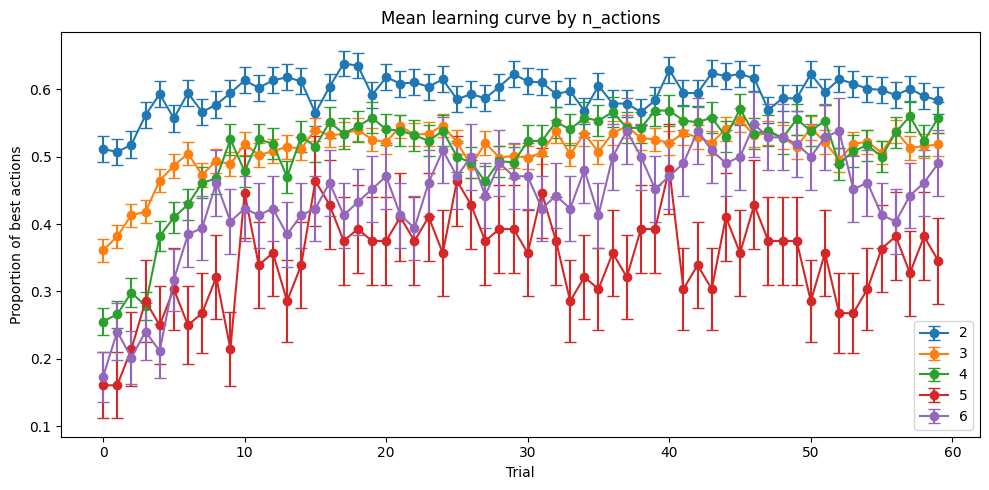

In [19]:
# plot descriptive learning curves across task families.
plot_learning_curve_by_task_type(feature_name='n_actions', max_trials=60)

# 2 Model Fitting

In [20]:
# preview tensor-formatted data used by recurrent models.
X_train, X_test, Y_train, Y_test = DM.get_tensor_data(tasks_subset=[selected_task])  # split sessions into train/test tensors
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

# (this is just a preview of the data format)


X_train shape: (16, 193, 23)
X_test shape: (3, 193, 23)
Y_train shape: (16, 193)
Y_test shape: (3, 193)


GRU model:
$$ z = x(t)\cdot W_{xz}^\top + h(t-1)\cdot W_{hz}^\top + b_z $$
$$ r = x(t)\cdot W_{xr}^\top + h(t-1)\cdot W_{hr}^\top + b_r $$
$$ \tilde h = \tanh[x(t)W_{xh}^\top + r\odot h(t-1)\cdot W_{hh}^\top + b_h] $$
$$ h(t) = (1-z)\odot h(t-1) + z\odot \tilde h $$